In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "ndv[jupyter,pygfx]",
#     "jupyter-rfb<=0.5.4",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
# ]
# ///

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import ndv
import numpy as np
import tifffile
from scipy import ndimage
from skimage import color, feature, measure, segmentation

In [3]:
# set the path to one of the *_Simple Segmentation.tif files
seg_path = "../../../_static/images/ilastik/ilastik_Simple Segmentation.tif"

In [4]:
# Load a mask
seg = tifffile.imread(seg_path)

In [5]:
print(seg.dtype)
print(type(seg))

uint8
<class 'numpy.ndarray'>


In [ ]:
# show the mask image
ndv.imshow(seg)

In [6]:
viewer = ndv.imshow(seg)

RFBOutputContext()

<IPython.core.display.Javascript object>

RFBOutputContext()

RFBOutputContext()


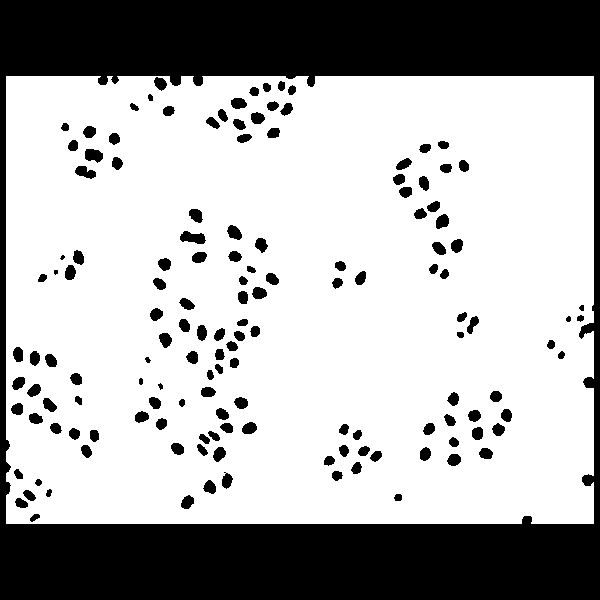

In [7]:
viewer.widget().children[1].snapshot()

In [8]:
# Convert to a binary mask
# The nuclei pixels have all value 1, the seg image is a numpy array.
# We can create a new bunary mask by keeping only the pixels with value 1.
binary_mask = seg == 1

In [ ]:
# ndv does not like boolean arrays -> convert to uint8 (from False/True to 0/1)
# print(binary_mask.dtype)
ndv.imshow(binary_mask.astype(np.uint8))

In [9]:
viewer = ndv.imshow(seg)

RFBOutputContext()

<IPython.core.display.Javascript object>


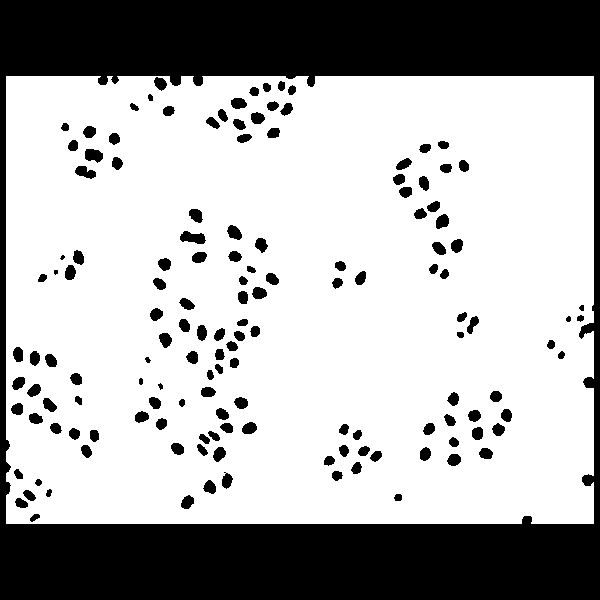

In [10]:
viewer.widget().children[1].snapshot()

In [11]:
# compute the distance transform
distance = ndimage.distance_transform_edt(binary_mask)
# find local maxima in the distance transform
local_maxima_coords = feature.peak_local_max(
    distance, footprint=np.ones((25, 25)), min_distance=10
)
# create a binary image from the local maxima coordinates
local_maxima = np.zeros_like(binary_mask, dtype=bool)
local_maxima[tuple(local_maxima_coords.T)] = True
# use the local maxima to create seeds for the watershed algorithm
seeds = measure.label(local_maxima)
# apply the watershed algorithm to segment the image and get labels
labels = segmentation.watershed(-distance, seeds, mask=binary_mask)

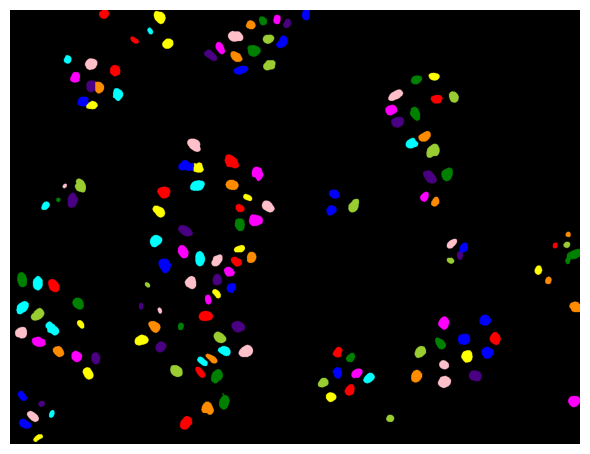

In [12]:
img = color.label2rgb(labels, bg_label=0)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
tifffile.imwrite("ilastik_Simple Segmentation_labels.tif", labels.astype("uint32"))

In [ ]:
# make a function to create labels from a _Simple Segmentation.tif file
def ilastik_seg_to_labels(seg_image: np.ndarray, object_index: int) -> np.ndarray:
    """Convert an ilastik simpole segmentation image to labeled image.

    Parameters
    ----------
    seg_image : np.ndarray
        The input segmentation image generated by ilastik.
    object_index : int
        The index of the object to segment (e.g. 1 if your objects have value 1).
    """
    # convert to a binary mask
    binary_mask = seg_image == object_index
    # compute the distance transform
    distance = ndimage.distance_transform_edt(binary_mask)
    # find local maxima in the distance transform
    local_maxima_coords = feature.peak_local_max(
        distance, footprint=np.ones((25, 25)), min_distance=10
    )
    # create a binary image from the local maxima coordinates
    local_maxima = np.zeros_like(binary_mask, dtype=bool)
    local_maxima[tuple(local_maxima_coords.T)] = True
    # use the local maxima to create seeds for the watershed algorithm
    seeds = measure.label(local_maxima)
    # apply the watershed algorithm to segment the image and get labels
    return segmentation.watershed(-distance, seeds, mask=binary_mask)


# set the input directory to the path of the _Simple Segmentation.tif files
input_dir = Path("my_input_directory")
# set the output directory to save the labels
output_dir = Path("my_output_directory")

for seg_file in input_dir.glob("*_Simple Segmentation.tif"):
    seg_image = tifffile.imread(seg_file)
    labels = ilastik_seg_to_labels(seg_image, object_index=1)
    output_file = output_dir / f"{seg_file.stem}_labels.tif"
    tifffile.imwrite(output_file, labels.astype("uint32"))